In [1]:
import numpy as np
import mne
import matplotlib.pyplot as plt

In [2]:
df_awake_60hz = mne.io.read_raw_edf('../data/XU/XUAWAKE60.EDF', preload=True)

Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUAWAKE60.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 156159  =      0.000 ...   609.996 secs...


In [3]:
print(df_awake_60hz.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T3, T5, O1, F3, C3, P3, A1, Fz, Cz, Fp2, F8, T4, T6, ...
 chs: 46 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-05-08 18:06:02 UTC
 nchan: 46
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, first_name: X, last_name: X>
>


In [4]:
df_awake_60hz.ch_names

['Fp1',
 'F7',
 'T3',
 'T5',
 'O1',
 'F3',
 'C3',
 'P3',
 'A1',
 'Fz',
 'Cz',
 'Fp2',
 'F8',
 'T4',
 'T6',
 'O2',
 'F4',
 'C4',
 'P4',
 'A2',
 'Fpz',
 'Pz',
 'T1',
 'T2',
 'EKGL',
 'EKGR',
 'LOC1',
 'LOC2',
 'EMG1',
 'EMG2',
 'X9',
 'X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X16',
 'X17',
 'X18',
 'DC1',
 'DC2',
 'DC3',
 'DC4',
 'OSAT',
 'PR']

### EEG Montage Analysis for XU Dataset
Looking at your complete channel list, this is a clinical polysomnography (sleep study) setup that combines:

1. Extended 10-20/10-10 EEG System (21+ electrodes)
2. Auxiliary physiological monitoring channels
3. Custom channels for the study

#### EEG Montage Breakdown
Standard 10-20 System Electrodes
- Frontal: Fp1, Fp2, F3, F4, F7, F8, Fz
- Central: C3, C4, Cz
- Parietal: P3, P4, Pz
- Occipital: O1, O2
- Temporal: T3, T4, T5, T6
- Reference: A1, A2 (mastoids/ear electrodes)
#### Extended 10-10 System Additions
- Midline: Fpz
- Temporal: T1, T2
#### Non-EEG Monitoring Channels
- Cardiac: EKGL, EKGR (left/right EKG leads)
- Eye movement: LOC1, LOC2 (electro-oculogram)
- Muscle activity: EMG1, EMG2 (electromyogram)
- Vital signs: OSAT (oxygen saturation), PR (pulse rate)
#### Study-Specific Channels
- Auxiliary: X9-X18 (likely additional recording sites)
- Direct Current: DC1-DC4 (possibly for slow wave activity or stimulation markers)

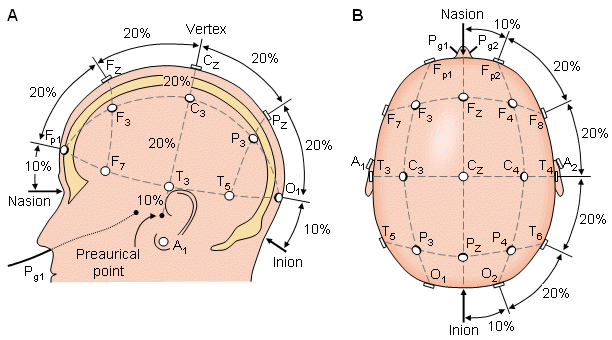

Shriram, R., Sundhararajan, Dr. M., & Daimiwal, N. (2012). EEG Based Cognitive Workload Assessment for Maximum Efficiency. ResearchGate. Retrieved from https://www.researchgate.net/publication/286371237_EEG_Based_Cognitive_Workload_Assessment_for_Maximum_Efficiency

Notes for Analysis
Naming Convention: dataset uses the older naming convention (T3/T4 instead of T7/T8) which is typical in clinical settings.

Reference: Check if  recordings are referenced to A1/A2 or if those are separate channels. Common references in sleep studies are:

Linked ears/mastoids (A1+A2)
Contralateral mastoid reference
Common average reference
Non-EEG Channels: For specialized analysis of:

Sleep stages: Use EEG + EOG (LOC1/LOC2) + EMG
Cardiac artifacts: Use EKG channels for correlation
Eye movement artifacts: Use LOC channels
DBS Analysis: To analyze deep brain stimulation effects, focus on the DC channels which may contain stimulation markers or the X9-X18 channels if they represent recording sites near stimulation areas

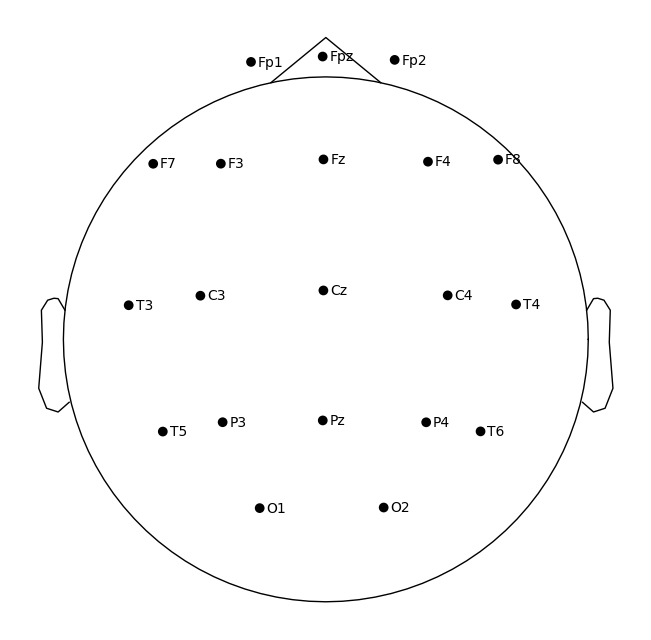

In [5]:
# Use only standard 10-20 system electrodes
standard_channels = ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 
                     'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 
                     'C4', 'P4', 'Fpz', 'Pz']

# Create a copy with just the standard channels
eeg_raw = df_awake_60hz.copy().pick(standard_channels)

# Apply the standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
eeg_raw.set_montage(montage)

# Visualize the montage
fig = eeg_raw.plot_sensors(show_names=True)

## Preprocessing Steps
1. **Filtering**: Apply bandpass filtering (e.g., 0.5-40 Hz) to remove noise and artifacts.
2. **Re-referencing**: Choose an appropriate reference scheme based on your analysis needs.
3. **Artifact Removal**: Use ICA or other methods to remove eye blinks, muscle artifacts, and cardiac artifacts.
4. **Epoching**: Segment data into epochs around events of interest (e.g., seizures, stimulation periods).
5. **Baseline Correction**: Apply baseline correction to epochs if necessary.

In [6]:
df_awake_60hz.filter(0.5, 40.)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)



<RawEDF | XUAWAKE60.EDF, 46 x 156160 (610.0 s), ~54.8 MiB, data loaded>

Using matplotlib as 2D backend.


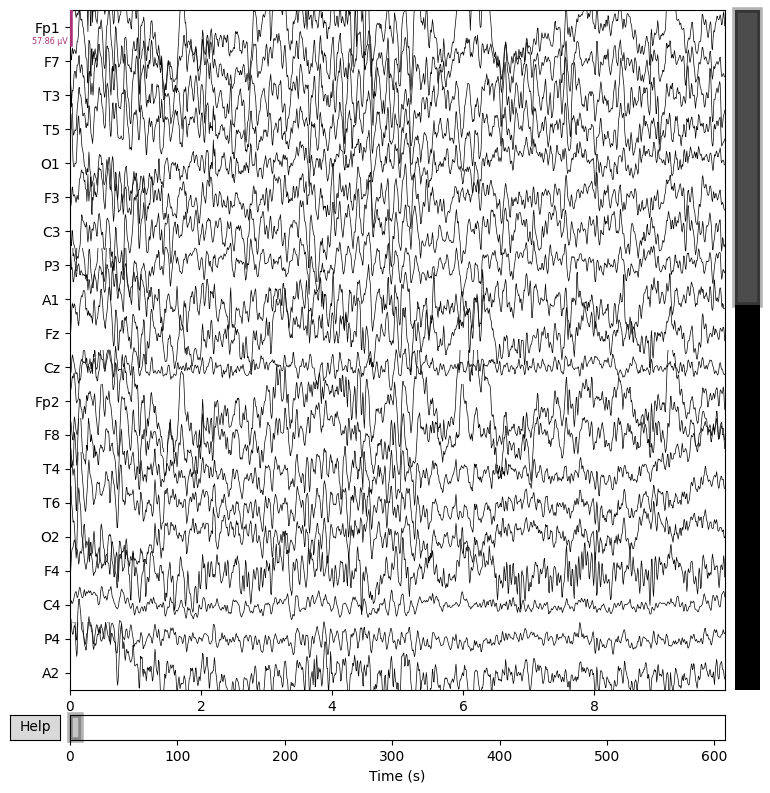

In [7]:
# MNE's plot method creates its own figure
fig = df_awake_60hz.plot(scalings='auto', title='Filtered EEG Data', show=True, block=True)

In [8]:
df_awake_60hz.set_eeg_reference(['A1', 'A2'])
df_awake_60hz.apply_proj()

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
No projector specified for this dataset. Please consider the method self.add_proj.


<RawEDF | XUAWAKE60.EDF, 46 x 156160 (610.0 s), ~54.8 MiB, data loaded>

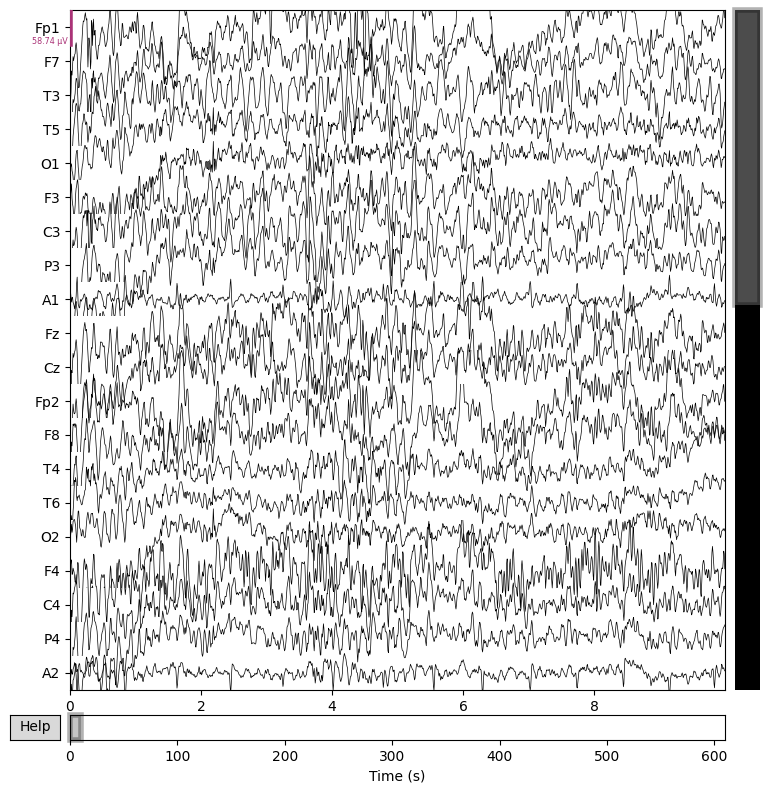

In [9]:
fig = df_awake_60hz.plot(scalings='auto', title='Filtered EEG Data', show=True, block=True)